In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
!ls

sample_data  test.csv


In [14]:
df = pd.read_csv('test.csv', encoding='latin-1')
df.head()


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


Checking for Missing Values and removing them

In [15]:
df.isnull().sum()

,0
textID,1281
text,1281
sentiment,1281
Time of Tweet,1281
Age of User,1281
Country,1281
Population -2020,1281
Land Area (Km²),1281
Density (P/Km²),1281


Drop rows with any null values

In [16]:
df.dropna(inplace=True)
df.isnull().sum()

,0
textID,0
text,0
sentiment,0
Time of Tweet,0
Age of User,0
Country,0
Population -2020,0
Land Area (Km²),0
Density (P/Km²),0


In [17]:
df.describe()

,Population -2020,Land Area (Km²),Density (P/Km²)
count,3.534000e+03,3.534000e+03,3534.000000
mean,3.941891e+07,6.722499e+05,348.894171
std,1.468757e+08,1.839134e+06,1967.012367
min,8.010000e+02,0.000000e+00,2.000000
25%,1.968001e+06,2.281000e+04,35.000000
50%,8.696453e+06,1.127600e+05,87.000000
75%,2.843594e+07,5.279700e+05,214.000000
max,1.439324e+09,1.637687e+07,26337.000000


Preparing the Data for Training

In [18]:
df = df[['text', 'sentiment']]
df = df.dropna()

X = df['text']
y = df['sentiment']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
y_test

,sentiment
325,positive
2226,negative
2480,positive
1862,neutral
299,neutral
...,...
1151,neutral
1949,neutral
2271,neutral
2736,positive


In [20]:
y_train

,sentiment
199,neutral
1352,positive
1850,neutral
801,neutral
2129,positive
...,...
1130,neutral
1294,positive
860,positive
3507,positive


Creating and Training the Model

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC())
])

text_clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LinearSVC())])

Evaluating the Model

In [22]:
predictions = text_clf.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.65      0.57      0.61       306
     neutral       0.60      0.64      0.62       423
    positive       0.69      0.71      0.70       332

    accuracy                           0.64      1061
   macro avg       0.65      0.64      0.64      1061
weighted avg       0.64      0.64      0.64      1061



Visualizing the Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, predictions)
cm

array([[175, 107,  24],
       [ 73, 269,  81],
       [ 21,  74, 237]])

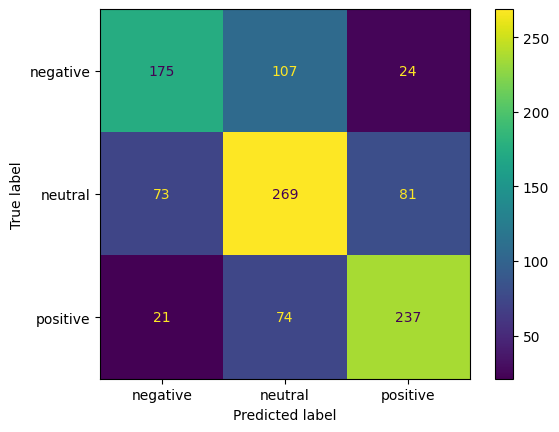

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=text_clf.classes_)
disp.plot()

Making Predictions with the Model

In [ ]:
text_clf.predict(['This is wery bad! i hate this product. do not recommend'])

array(['negative'], dtype=object)

In [ ]:
text_clf.predict(['It looks fine'])

array(['neutral'], dtype=object)

In [ ]:
text_clf.predict(['Something like 69.'])

array(['negative'], dtype=object)

In [26]:
text_clf.predict(['I am so happy to share this with you...'])

array(['positive'], dtype=object)

In [25]:
text_clf.predict(['I think this might end badly.'])

array(['neutral'], dtype=object)